In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# --- 1. DATASET GENERATION ---

# Set seed for reproducibility
np.random.seed(42)

# Generate 200 candidate records over a 6-month period
date_range = pd.date_range(start='2023-06-01', periods=200, freq='H')
n_samples = len(date_range)

# Features
experience_years = np.random.randint(0, 15, n_samples)
education_quality_raw = np.random.randint(50, 100, n_samples) # Pre-calc score for education
skills_match_raw = np.random.randint(20, 40, n_samples)       # Pre-calc score for skills

# Target Variable: Total Score (Simulating your calculate_rigorous_score logic)
# Formula: Base + (Exp * multiplier) + Education + Skills + Random Noise
total_score_actual = (20 +
                     (experience_years * 2.5) +
                     (education_quality_raw * 0.3) +
                     (skills_match_raw * 0.5) +
                     np.random.normal(0, 5, n_samples))

# Clip score to 0-100 range
total_score_actual = np.clip(total_score_actual, 0, 100).round(2)

# Create DataFrame
df = pd.DataFrame({
    'Date': date_range,
    'Candidate_ID': range(1, n_samples + 1),
    'Experience_Years': experience_years,
    'Education_Raw_Score': education_quality_raw,
    'Skills_Raw_Score': skills_match_raw,
    'Total_Score': total_score_actual
})

print("Dataset Created Successfully.")
df.head()

Dataset Created Successfully.


,Date,Candidate_ID,Experience_Years,Education_Raw_Score,Skills_Raw_Score,Total_Score
0,2023-06-01 00:00:00,1,6,86,33,83.32
1,2023-06-01 01:00:00,2,3,72,25,55.62
2,2023-06-01 02:00:00,3,12,88,22,91.25
3,2023-06-01 03:00:00,4,14,94,28,100.00
4,2023-06-01 04:00:00,5,10,64,24,72.70


In [ ]:
# --- 2. DATASET INFORMATION ---

print("=" * 40)
print("A. Dataset Structure (Info)")
print("=" * 40)
print(df.info())

print("\n" + "=" * 40)
print("B. Statistical Summary")
print("=" * 40)
print(df.describe())

print("\n" + "=" * 40)
print("C. Missing Values")
print("=" * 40)
print(df.isnull().sum())

A. Dataset Structure (Info)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 200 non-null    datetime64[ns]
 1   Candidate_ID         200 non-null    int64         
 2   Experience_Years     200 non-null    int64         
 3   Education_Raw_Score  200 non-null    int64         
 4   Skills_Raw_Score     200 non-null    int64         
 5   Total_Score          200 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 9.5 KB
None

B. Statistical Summary
                                Date  Candidate_ID  Experience_Years  \
count                            200    200.000000        200.000000   
mean   2023-06-05 03:30:00.000000256    100.500000          7.450000   
min              2023-06-01 00:00:00      1.000000          0.000000   
25%              2023-06-0

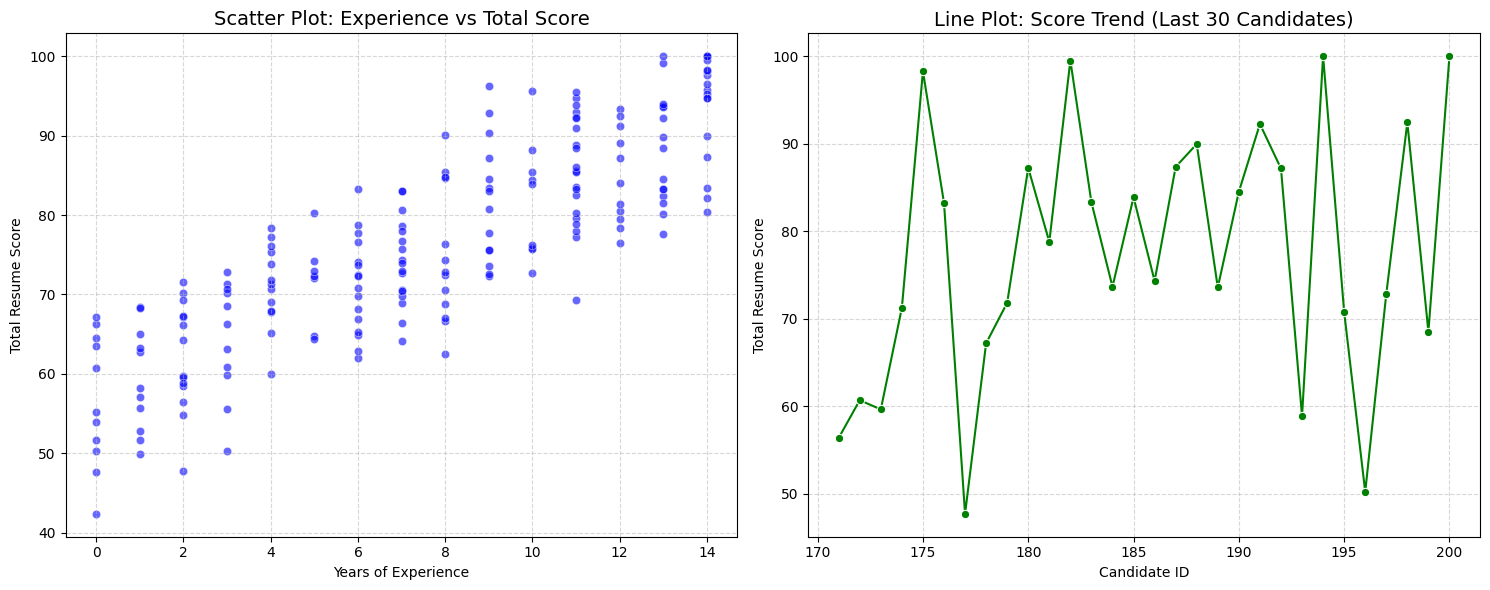

In [ ]:
# --- 3. SCATTER PLOT AND LINE PLOT ---

plt.figure(figsize=(15, 6))

# Subplot 1: Scatter Plot (Experience vs Total Score)
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Experience_Years', y='Total_Score', color='blue', alpha=0.6)
plt.title('Scatter Plot: Experience vs Total Score', fontsize=14)
plt.xlabel('Years of Experience')
plt.ylabel('Total Resume Score')
plt.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Line Plot (Trend of last 30 candidates)
plt.subplot(1, 2, 2)
recent_data = df.tail(30)
sns.lineplot(data=recent_data, x='Candidate_ID', y='Total_Score', marker='o', color='green')
plt.title('Line Plot: Score Trend (Last 30 Candidates)', fontsize=14)
plt.xlabel('Candidate ID')
plt.ylabel('Total Resume Score')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

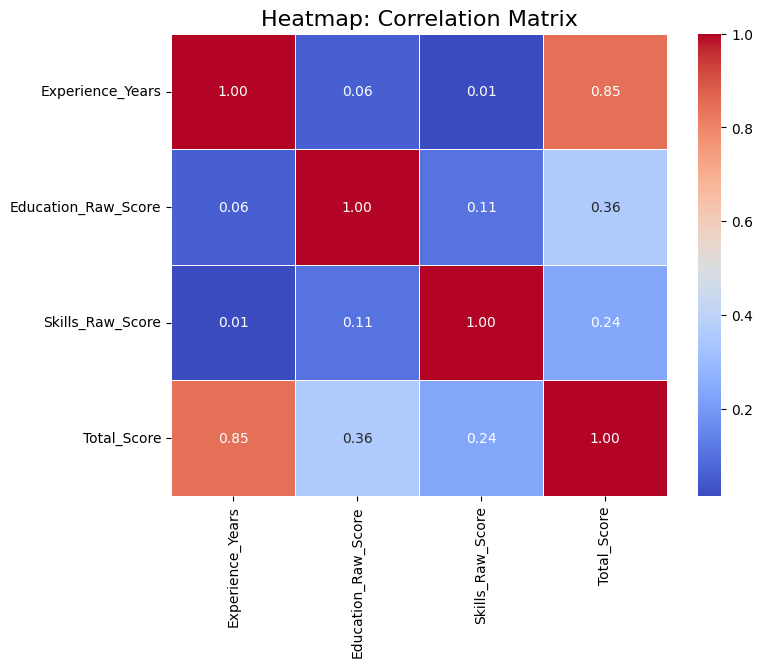

In [ ]:
# --- 4. HEATMAP ---

# Calculate correlation
corr_matrix = df[['Experience_Years', 'Education_Raw_Score', 'Skills_Raw_Score', 'Total_Score']].corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap: Correlation Matrix', fontsize=16)
plt.show()

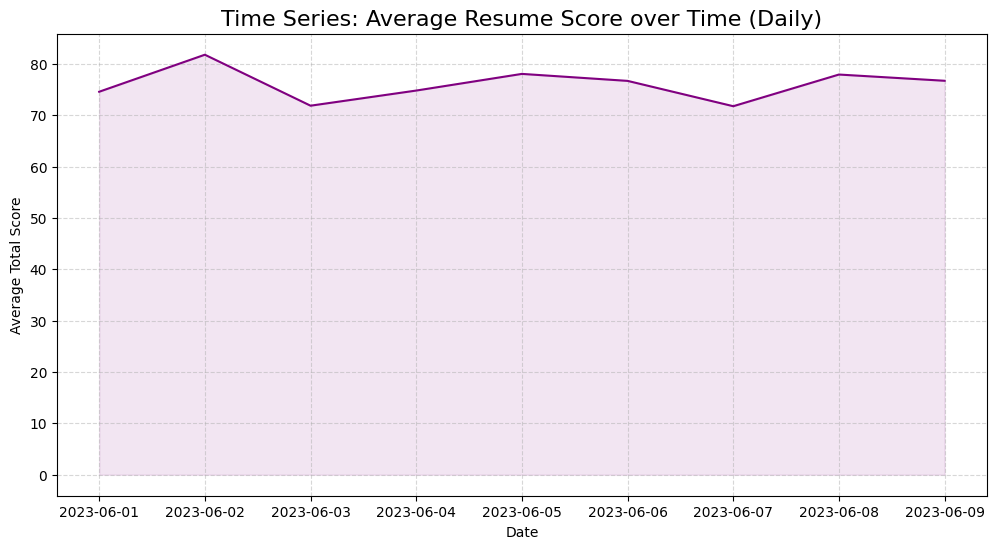

In [ ]:
# --- 5. TIME SERIES REPRESENTATION ---

# Resample data by Day ('D') and calculate the mean score
time_series_data = df.set_index('Date').resample('D')['Total_Score'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=time_series_data.index, y=time_series_data.values, color='purple')
plt.title('Time Series: Average Resume Score over Time (Daily)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Average Total Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.fill_between(time_series_data.index, time_series_data.values, color='purple', alpha=0.1)
plt.show()

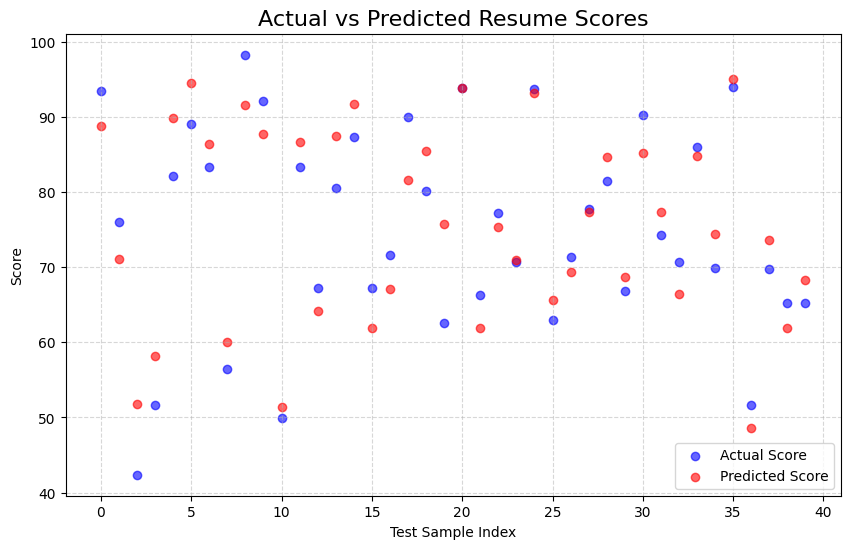

In [ ]:
# --- 6. ACTUAL VS PREDICTED ---

# Define Features (X) and Target (y)
X = df[['Experience_Years', 'Education_Raw_Score', 'Skills_Raw_Score']]
y = df['Total_Score']

# Split into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Create a comparison DataFrame
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison_df = comparison_df.reset_index(drop=True)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(comparison_df.index, comparison_df['Actual'], color='blue', label='Actual Score', alpha=0.6)
plt.scatter(comparison_df.index, comparison_df['Predicted'], color='red', label='Predicted Score', alpha=0.6)
plt.title('Actual vs Predicted Resume Scores', fontsize=16)
plt.xlabel('Test Sample Index')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

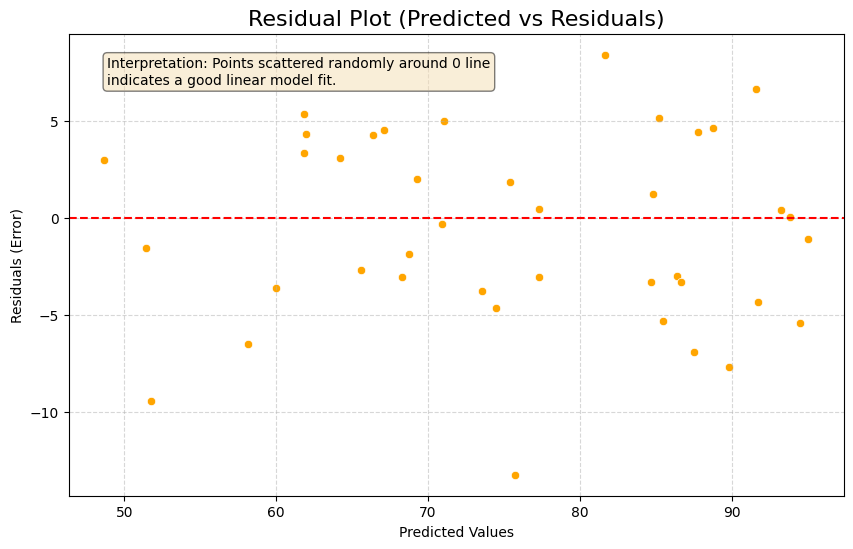

In [ ]:
# --- 7. RESIDUAL PLOT ---

# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, color='orange')
plt.axhline(y=0, color='r', linestyle='--') # Horizontal line at 0
plt.title('Residual Plot (Predicted vs Residuals)', fontsize=16)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Error)')
plt.grid(True, linestyle='--', alpha=0.5)

# Interpretation text
plt.text(0.05, 0.95,
         "Interpretation: Points scattered randomly around 0 line\nindicates a good linear model fit.",
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()